# Model Evaluation

Evaluation of the two U-Net models trained to segment the optic **cup** and optic **disc** on the ORIGA fundus dataset.
Results are pre-computed by [`evaluate.py`](evaluate.py) - no model loading is required to render this notebook.
All reusable functions live in [`analysis_utils.py`](analysis_utils.py).

In [57]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS_DIR = Path("results")
RUNS_DIR = Path("..") / "runs"

with open(RESULTS_DIR / "metrics.json") as f:
    m = json.load(f)

cup_df  = pd.read_csv(RUNS_DIR / "cup_256_unet"  / "training_history.csv")
disc_df = pd.read_csv(RUNS_DIR / "disc_256_unet" / "training_history.csv")

## Section 1: Training Diagnostics

**Final epoch chosen.**
The saved `best.h5` checkpoint corresponds to the epoch that maximises `val_dice_coef`, selected automatically by `ModelCheckpoint(monitor="val_dice_coef", save_best_only=True)`.
Training was then terminated by `EarlyStopping(monitor="val_dice_coef", patience=10)` once no further improvement was observed for 10 consecutive epochs.

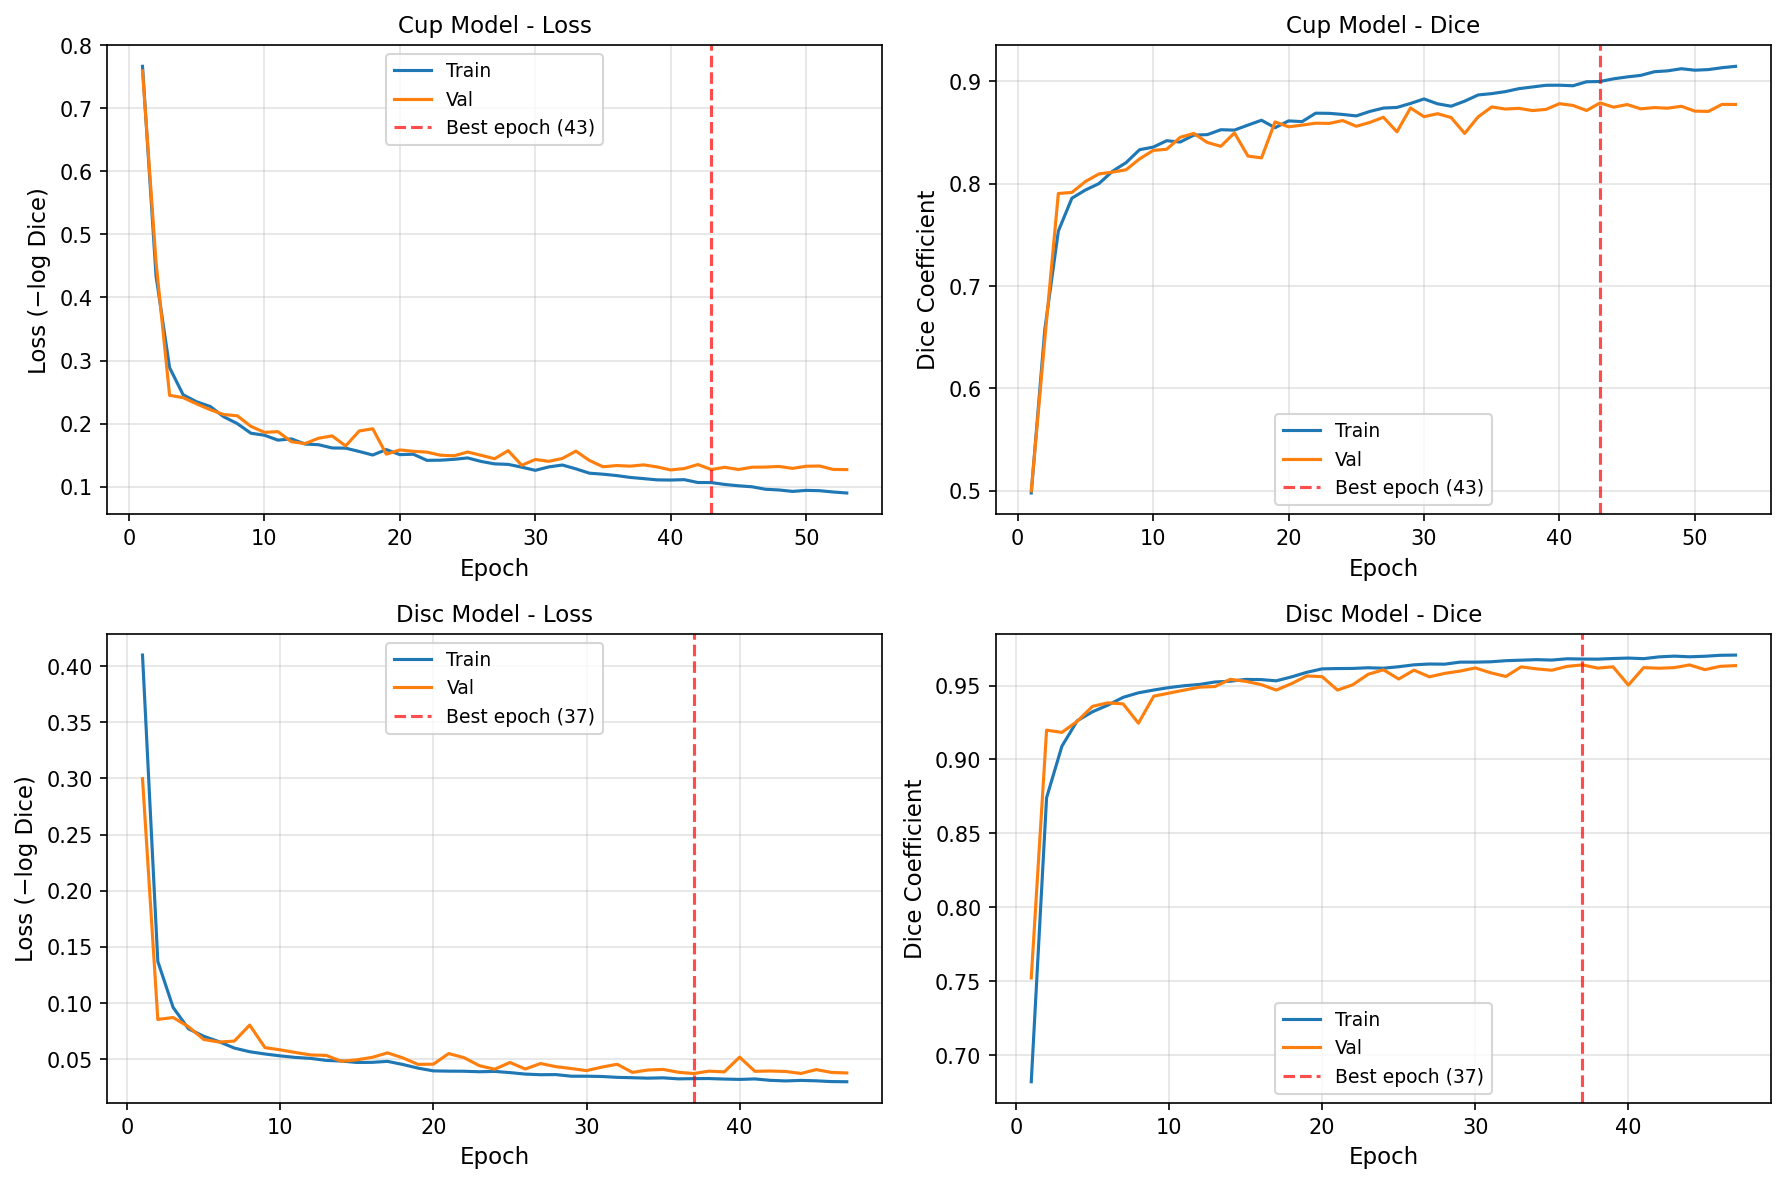

In [58]:
display(Image(filename=str(RESULTS_DIR / "training_curves.png")))

In [59]:
cup_best_idx  = cup_df["val_dice_coef"].idxmax()
disc_best_idx = disc_df["val_dice_coef"].idxmax()

perf_df = pd.DataFrame({
    "Cup model": {
        "Best epoch": m["cup"]["best_epoch"],
        "Train Dice": f'{m["cup"]["train_dice_at_best"]:.4f}',
        "Val Dice":   f'{m["cup"]["best_val_dice"]:.4f}',
        "Train Loss": f'{cup_df.loc[cup_best_idx, "loss"]:.4f}',
        "Val Loss":   f'{cup_df.loc[cup_best_idx, "val_loss"]:.4f}',
    },
    "Disc model": {
        "Best epoch": m["disc"]["best_epoch"],
        "Train Dice": f'{m["disc"]["train_dice_at_best"]:.4f}',
        "Val Dice":   f'{m["disc"]["best_val_dice"]:.4f}',
        "Train Loss": f'{disc_df.loc[disc_best_idx, "loss"]:.4f}',
        "Val Loss":   f'{disc_df.loc[disc_best_idx, "val_loss"]:.4f}',
    },
})
perf_df

,Cup model,Disc model
Best epoch,43,37
Train Dice,0.8997,0.9679
Val Dice,0.8788,0.9639
Train Loss,0.1064,0.0327
Val Loss,0.1271,0.0372


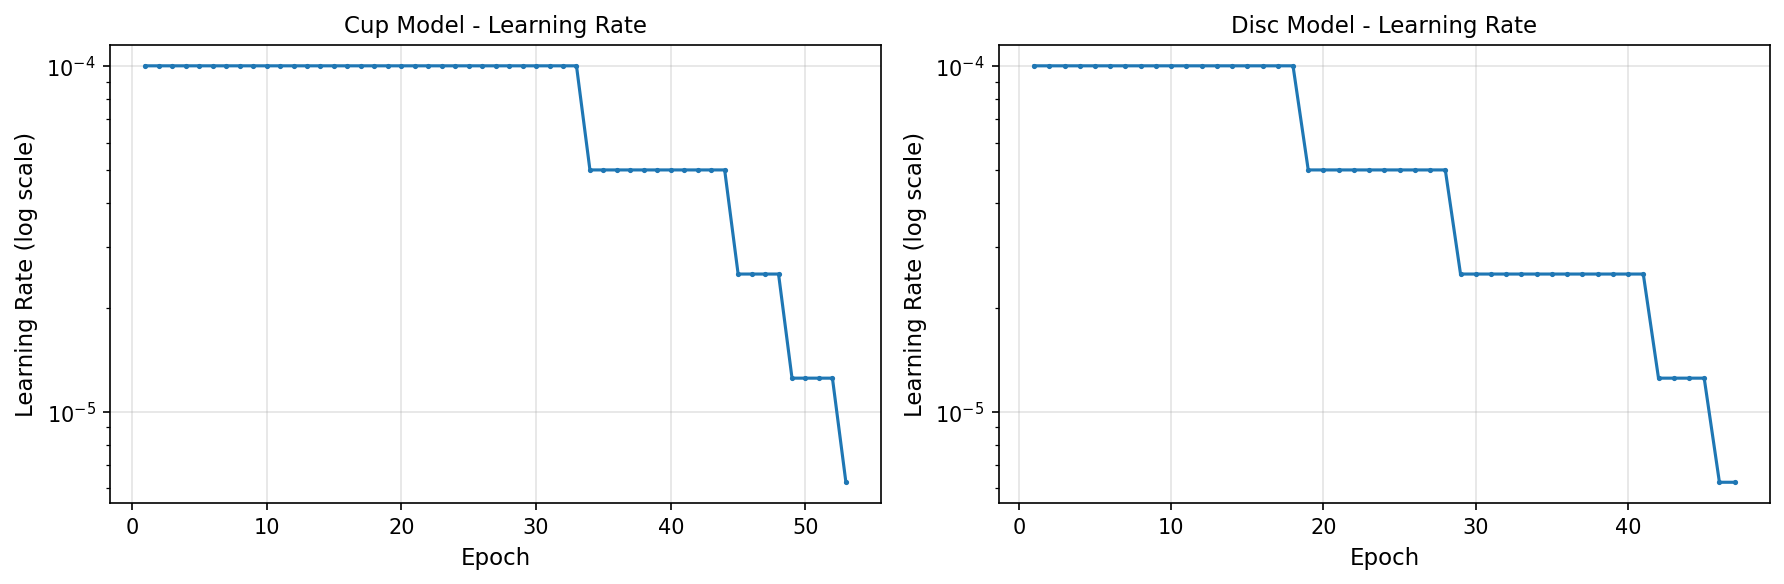

In [60]:
display(Image(filename=str(RESULTS_DIR / "lr_schedule.png")))

**Learning-rate schedule.**
Both models used **Adam** with an initial LR of **1 × 10⁻⁴**.
`ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)` halved the LR whenever validation loss failed to improve for 4 consecutive epochs; the step-wise drops visible above mark each plateau trigger.

**Comments**

Disc:

- **Convergence and LR schedule.** A `ReduceLROnPlateau` schedule reduced the learning rate from 1e-4 to 6.25e-6 across the run. Each reduction produced clear training-loss gains but smaller, noisier gains on validation; by the final reduction the model had effectively converged.
- **Generalisation.** Validation loss did not increase, but a small train/val gap developed in the later epochs, confirming the value of early stopping with best-weights restoral.
- **Checkpoint selection.** Epoch 37 sits within a plateau of statistically indistinguishable epochs (33, 36, 37, 39, 44, 46, 47), all within ~0.002 Dice of one another - well inside the validation noise observed elsewhere in the run (e.g. the epoch 40 spike). Epoch 37 is therefore defensible as one of several equivalent checkpoints rather than a clearly superior one; it wins on a noisy tiebreaker, as evidenced by epoch 38 immediately regressing rather than holding near the epoch 37 level.

Cup:

- **Run is healthy but the harder task is exposing mild overfitting.** Validation plateaued around epoch 30 while training loss continued to fall; the train/val Dice gap widened from ~0.018 at epoch 30 to ~0.037 by epoch 53. Validation is not degrading, only stagnant, but the optimiser is no longer doing useful work for generalisation past ~epoch 30. LR reductions at epochs 34, 45, 49 and 53 produced clear training gains but only marginal validation gains.
- **Capacity to spare.** The model can fit more, but the data does not contain sufficient generalisable signal to use that capacity productively.
- **Bias-variance frontier.** Performance is at the limit of what this dataset supports under the current recipe. Further gains require changes to the data or regularisation (stronger augmentation, additional or higher-quality labels, dropout), not extended training.
- **Validation noise.** Notable epoch-to-epoch drops at epochs 14, 17–18 (val_dice ~0.825), 28 and 33 are consistent with a small or harder validation set where individual samples carry disproportionate weight. Larger validation folds or k-fold cross-validation would provide more reliable model selection.

## Section 2: Performance on Test Set


The test set is the final **65 samples** (10 % of 650) selected by the same split used in `trainer.py` (samples 586–650 in lexicographic order).

In [61]:
stats_df = pd.DataFrame({
    "Cup Model": {
        "Mean Dice":            f'{m["cup"]["mean_dice"]:.4f}',
        "Std Dev":              f'{m["cup"]["stats"]["std"]:.4f}',
        "Median":               f'{m["cup"]["stats"]["median"]:.4f}',
        "IQR [Q25, Q75]":      f'[{m["cup"]["stats"]["q25"]:.4f}, {m["cup"]["stats"]["q75"]:.4f}]',
        "95 % CI (bootstrap)": f'[{m["cup"]["ci_low"]:.4f}, {m["cup"]["ci_high"]:.4f}]',
    },
    "Disc Model": {
        "Mean Dice":            f'{m["disc"]["mean_dice"]:.4f}',
        "Std Dev":              f'{m["disc"]["stats"]["std"]:.4f}',
        "Median":               f'{m["disc"]["stats"]["median"]:.4f}',
        "IQR [Q25, Q75]":      f'[{m["disc"]["stats"]["q25"]:.4f}, {m["disc"]["stats"]["q75"]:.4f}]',
        "95 % CI (bootstrap)": f'[{m["disc"]["ci_low"]:.4f}, {m["disc"]["ci_high"]:.4f}]',
    },
})
stats_df

,Cup Model,Disc Model
Mean Dice,0.8833,0.9675
Std Dev,0.0619,0.0180
Median,0.9013,0.9728
"IQR [Q25, Q75]","[0.8551, 0.9253]","[0.9589, 0.9793]"
95 % CI (bootstrap),"[0.8668, 0.8970]","[0.9626, 0.9716]"


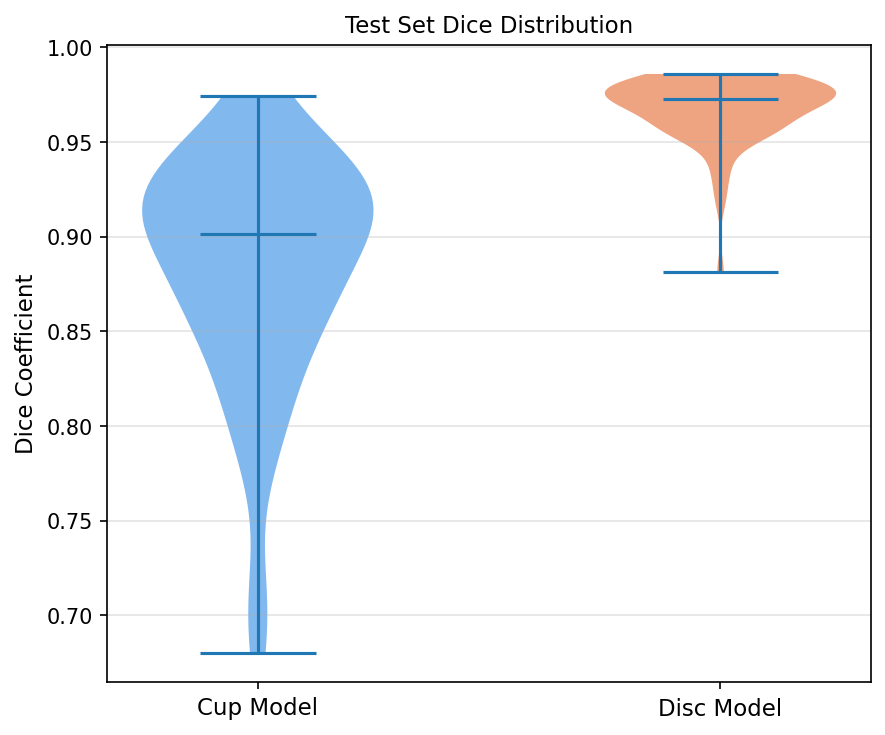

In [62]:
display(Image(filename=str(RESULTS_DIR / "dice_violin.png")))

In [63]:
comp_df = pd.DataFrame({
    "Cup Model": {
        "Train Dice (best epoch)":    f'{m["cup"]["train_dice_at_best"]:.4f}',
        "Val Dice (best epoch)":      f'{m["cup"]["best_val_dice"]:.4f}',
        "Test Dice (mean, 95 % CI)":  f'{m["cup"]["mean_dice"]:.4f}  (95 % CI: {m["cup"]["ci_low"]:.4f}–{m["cup"]["ci_high"]:.4f})',
    },
    "Disc Model": {
        "Train Dice (best epoch)":    f'{m["disc"]["train_dice_at_best"]:.4f}',
        "Val Dice (best epoch)":      f'{m["disc"]["best_val_dice"]:.4f}',
        "Test Dice (mean, 95 % CI)":  f'{m["disc"]["mean_dice"]:.4f}  (95 % CI: {m["disc"]["ci_low"]:.4f}–{m["disc"]["ci_high"]:.4f})',
    },
})
comp_df

,Cup Model,Disc Model
Train Dice (best epoch),0.8997,0.9679
Val Dice (best epoch),0.8788,0.9639
"Test Dice (mean, 95 % CI)",0.8833 (95 % CI: 0.8668–0.8970),0.9675 (95 % CI: 0.9626–0.9716)


**Generalisation:**

Both models show test Dice close to their best validation Dice, indicating that the single train/val/test split has not produced systematic optimism.
The cup model shows a slightly wider train–test gap, consistent with the smaller and more variable size of optic cups across patients.
The disc model generalises more cleanly: the disc boundary is less ambiguous and more stable across images, which is reflected in its higher overall Dice and narrower confidence interval.

## Section 3: Visualisations



Each figure shows three test samples for one model: **best**, **median**, and **worst** cases by that model's per-sample Dice score.
Green contour = ground-truth boundary; red contour = predicted boundary.
Best/median/worst are chosen **independently** for each model.

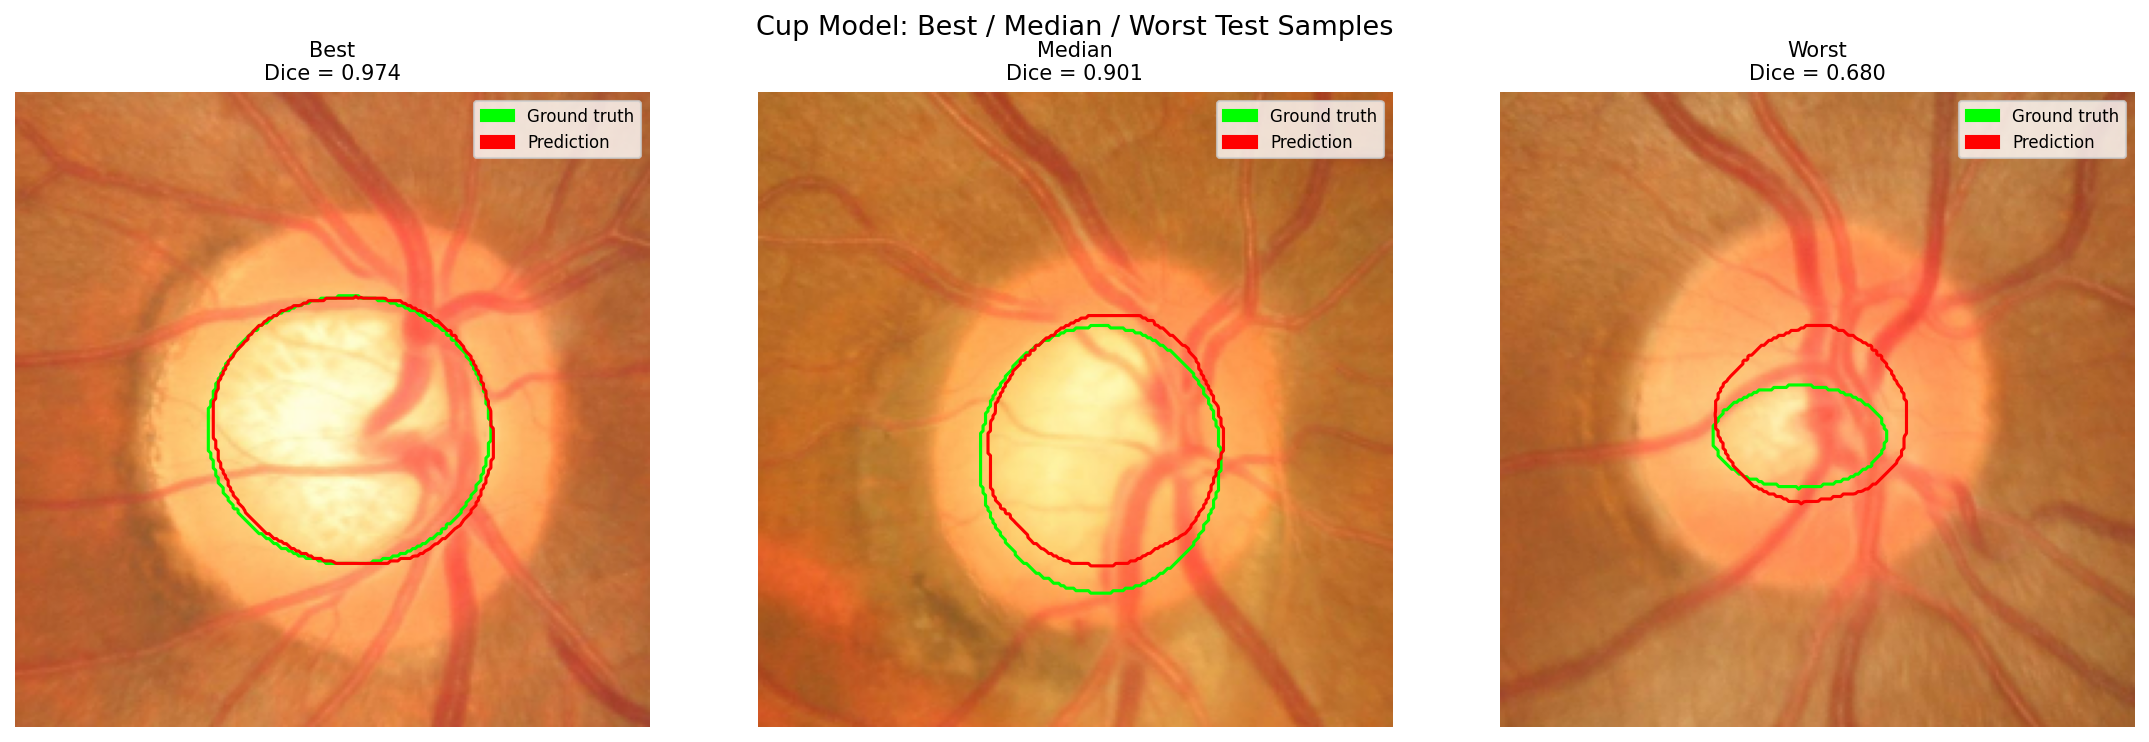

In [64]:
display(Image(filename=str(RESULTS_DIR / "cup_overlay.png")))

**Figure 1 - Cup model.**
*Left (best):* The model correctly delineates a well-defined, roughly circular cup with strong contrast against the surrounding disc tissue; predicted and ground-truth contours are nearly coincident.
*Centre (median):* A representative case; the model captures the overall cup extent but may slightly under- or over-segment near the cup rim where intensity gradients are shallower.
*Right (worst):* Hard cases typically involve very small cups (sparse foreground pixels make Dice noisier), highly eccentric or crescent-shaped cups, or poor illumination at the disc centre. These factors create an inherently ambiguous boundary that the model fails to resolve cleanly.

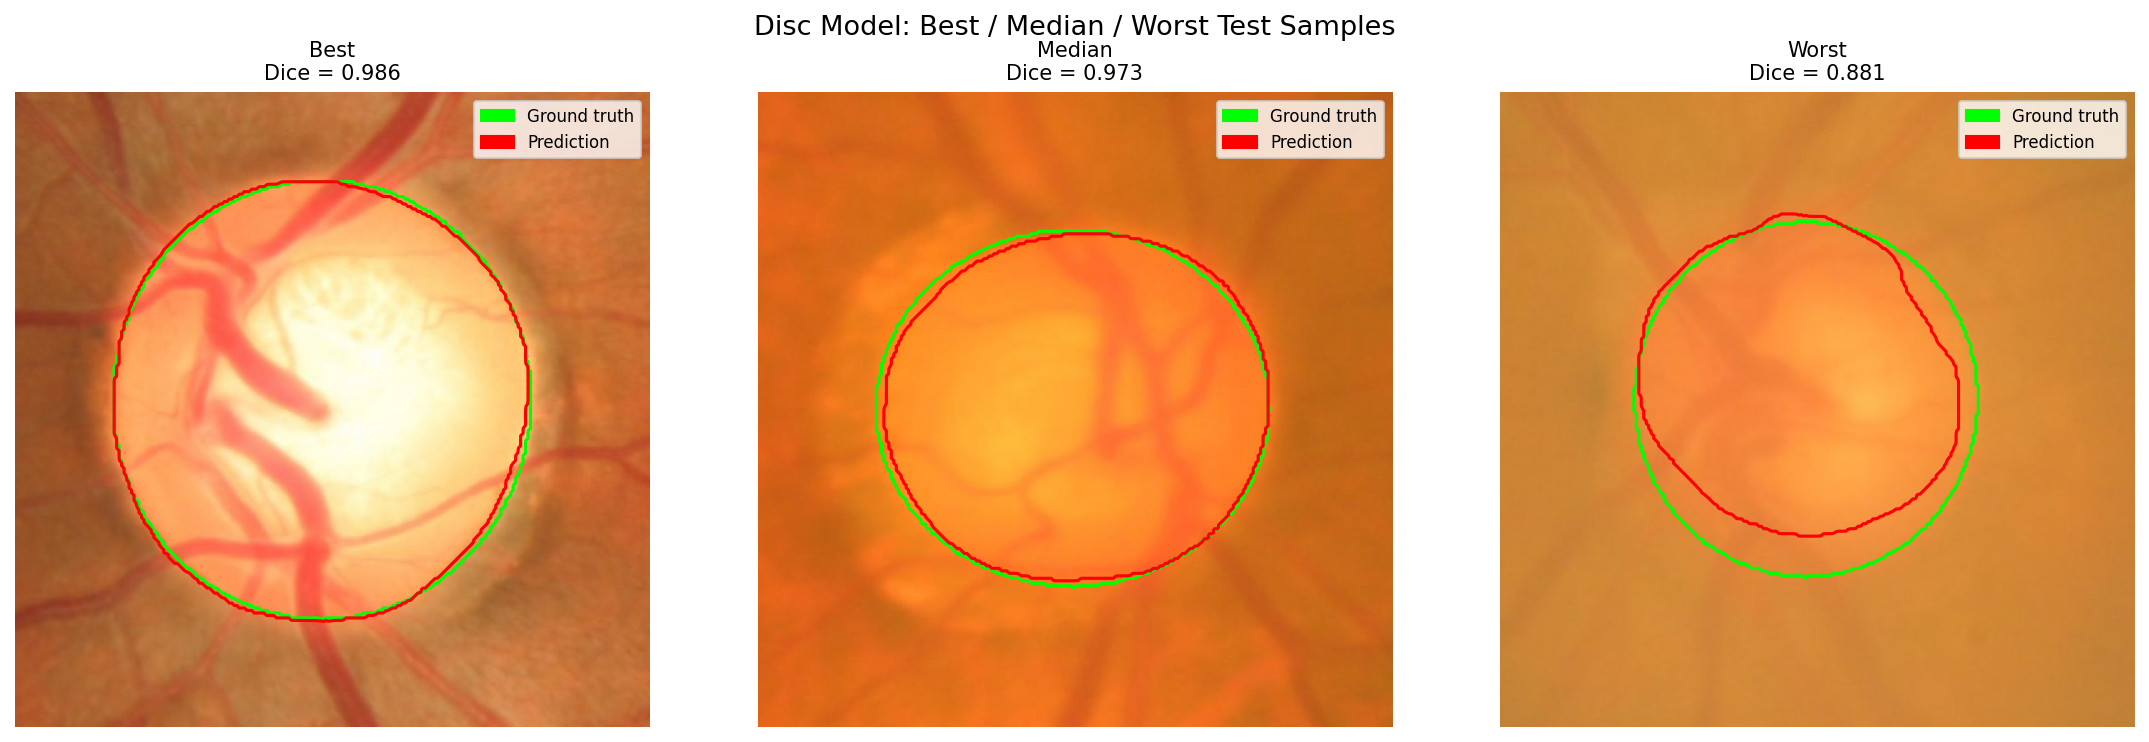

In [65]:
display(Image(filename=str(RESULTS_DIR / "disc_overlay.png")))

**Figure 2 - Disc model.**
*Left (best):* The disc boundary is clearly visible and the model produces a contour that closely follows the ground-truth annotation. Disc segmentation benefits from higher contrast between disc tissue and the surrounding retina, which is reflected in the generally higher Dice scores.
*Centre (median):* Minor discrepancies at the disc margin - near retinal vessels or peripapillary atrophy - cause small localised prediction offsets.
*Right (worst):* Challenging disc cases typically involve strongly tilted optic discs, peripapillary haemorrhage, or heavy pigmentation that obscures the boundary for both the model and human annotators.

## Section 4: Future Work



**k-Fold cross-validation.**
The current evaluation rests on a single 80/10/10 split; performance estimates are therefore sensitive to which 65 samples land in the test fold.  A stratified k-fold scheme (e.g. k = 5, stratified by glaucoma label) would train k separate models and average performance across held-out folds, yielding a more statistically robust generalisation estimate.

**Model ensembling.**
Averaging predictions from the best-epoch and final-epoch checkpoints (or from models trained with different random seeds) could reduce per-sample prediction variance, particularly for the cup model which shows higher variability.


## Section 5: Reproducibility



### Dataset split

| Split | Size | Fraction | Samples (1-indexed) |
|-------|------|----------|---------------------|
| Train | 520  | 80 %     | 001–520             |
| Val   |  65  | 10 %     | 521–585             |
| Test  |  65  | 10 %     | 586–650             |

The split is **fully deterministic**: stack and mask files are sorted lexicographically (001–650) and selected with `tf.data.Dataset.take` / `skip`. No random seed is needed or used for the split itself.

### Random state

| Component | Seed / behaviour |
|-----------|-----------------|
| Data split | Deterministic - sorted file order, no pre-split shuffle |
| Weight initialisation | `SEED = 42` (`tf.random.set_seed`, `np.random.seed`, `random.seed`, `PYTHONHASHSEED`) |
| Data augmentation (train only) | Per-batch stateless ops; global seed inherited from `tf.random.set_seed` |
| GPU determinism | `TF_DETERMINISTIC_OPS=1` enforces deterministic cuDNN kernels |
| Bootstrap CI (this notebook) | `numpy.random.default_rng(seed=42)` |


### Environment

| Package | Version |
|---------|---------|
| Python | 3.10.0 |
| TensorFlow | 2.18.1 |
| NumPy | 2.0.2 |
| Pandas | 2.3.3 |
| OpenCV | 4.13.0.90 |
| Pillow | 12.1.0 |
| SciPy | 1.15.3 |
| scikit-learn | 1.7.2 |
| Matplotlib | 3.10.8 |

OS: Windows 11 Pro (10.0.26200)